# Projet #3 - Prédiction du Churn Client
## Notebook 2 - Modélisation, compréhension et validation

Objectif : montrer que l'on comprend **pourquoi** un modèle est utile, pas seulement afficher un score.

Dans ce notebook :
- on commence par un modèle naïf de référence ;
- on compare Régression Logistique, Arbre de Décision et Random Forest ;
- on analyse les erreurs avec la matrice de confusion ;
- on compare les performances train/test pour vérifier le sur-apprentissage ;
- on teste plusieurs seuils de décision (40 %, 50 %, 60 %) ;
- on termine par des limites et des recommandations métier simples.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
)

# Retrouver le projet depuis sa racine ou depuis le dossier notebooks.
# Les notebooks importent le script pour utiliser exactement les mêmes règles.
import sys
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src/train.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src/train.py").exists():
    raise FileNotFoundError("Ouvrez le notebook depuis le projet ou son dossier notebooks.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.train import (
    RANDOM_STATE, TEST_SIZE, load_data, clean_data, split_features_target,
    build_preprocessor, get_models, optimize_models, evaluate_model, save_results,
)

sns.set_theme(style="whitegrid")

# Repartir du même CSV brut que le script évite d'utiliser un export nettoyé périmé.
# Le notebook 1 reste utile pour explorer les données, mais son export n'est pas requis ici.
df = clean_data(load_data())
X, y = split_features_target(df)
print("Taille du dataset :", df.shape)
print("Taux de churn :", round(y.mean() * 100, 2), "%")


Taille du dataset : (7043, 21)
Taux de churn : 26.54 %


## 1. Séparer les données

On utilise 80 % des données pour apprendre et 20 % pour tester.

Le jeu de test est gardé de côté jusqu'à la fin : il représente de nouvelles données que le modèle n'a jamais vues.


In [2]:
# La séparation utilise les mêmes paramètres que le script.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)


Train : (5634, 19)
Test  : (1409, 19)


## 2. Baseline naïve : pourquoi l'Accuracy ne suffit pas

Avant de faire du Machine Learning, on crée un modèle très simple qui prédit toujours la classe majoritaire : **pas de churn**.

Comme environ 73,5 % des clients ne churnent pas, ce modèle peut déjà avoir une Accuracy élevée.
Mais son Recall pour les churners est nul : il ne détecte aucun client qui part.

C'est une bonne démonstration du fait que l'Accuracy seule peut être trompeuse.


In [3]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

pd.DataFrame([{
    "Modèle": "Baseline naïve",
    "Accuracy": accuracy_score(y_test, dummy_pred),
    "Precision": precision_score(y_test, dummy_pred, zero_division=0),
    "Recall": recall_score(y_test, dummy_pred, zero_division=0),
    "F1": f1_score(y_test, dummy_pred, zero_division=0),
}]).set_index("Modèle").round(4)


,Accuracy,Precision,Recall,F1
Modèle,,,,
Baseline naïve,0.7346,0.0,0.0,0.0


### À dire à l'oral

> Une Accuracy correcte ne veut pas forcément dire que le modèle est utile. La baseline naïve prédit presque toujours 'pas de churn', donc elle paraît correcte globalement mais elle ne détecte aucun churner.


## 3. Comparaison de trois modèles simples

On compare :
- Régression Logistique : simple et interprétable ;
- Arbre de Décision : facile à visualiser comme une suite de questions ;
- Random Forest : plusieurs arbres combinés pour obtenir un modèle plus robuste.


In [4]:
# Les modèles de départ sont définis dans src/train.py.
models = get_models()

def evaluate(name, model):
    # Chaque modèle possède son propre prétraitement, appris sur le train uniquement.
    pipe = Pipeline([("prep", build_preprocessor(X_train)), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    return pipe, {
        "Modèle": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
    }

fitted_models = {}
rows = []
for name, model in models.items():
    fitted, metrics = evaluate(name, model)
    fitted_models[name] = fitted
    rows.append(metrics)

pd.DataFrame(rows).set_index("Modèle").round(4)


,Accuracy,Precision,Recall,F1,ROC-AUC
Modèle,,,,,
Régression logistique,0.7381,0.5043,0.7834,0.6136,0.8413
Arbre de décision,0.7559,0.5279,0.7594,0.6228,0.8324
Random Forest,0.7672,0.5542,0.6283,0.5890,0.8212


## 4. Analyse des erreurs avec la matrice de confusion

Une matrice de confusion permet de voir le type d'erreur commis par le modèle.

- Vrai positif : churn prédit et churn réel.
- Faux positif : churn prédit mais le client reste.
- Faux négatif : le modèle prédit qu'il reste mais le client churn.
- Vrai négatif : pas de churn prédit et pas de churn réel.

Dans notre cas, le faux négatif peut être coûteux : l'entreprise ne voit pas venir le départ du client.


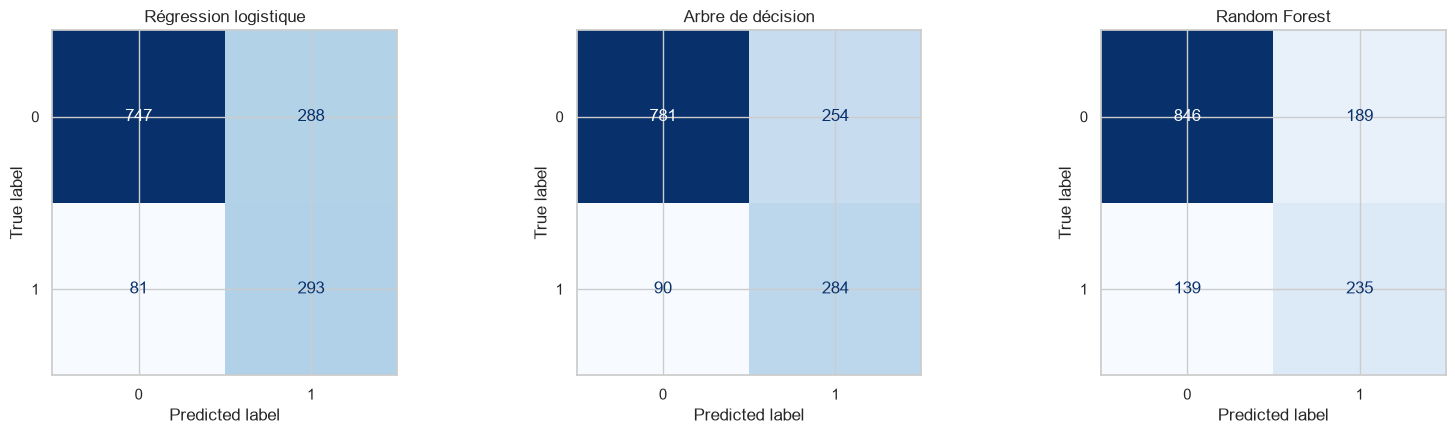

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, pipe) in zip(axes, fitted_models.items()):
    ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test, ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


### À dire à l'oral

> Je regarde surtout les faux négatifs, car ce sont les clients réellement à risque que le modèle n'a pas détectés.


## 5. Vérifier le sur-apprentissage : train vs test

Un modèle peut être très bon sur les données qu'il connaît et moins bon sur de nouvelles données.

On compare donc le score sur le train et sur le test. Si l'écart est très grand, cela peut indiquer du sur-apprentissage (overfitting).


In [6]:
comparison_rows = []
for name, pipe in fitted_models.items():
    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)
    comparison_rows.append({
        "Modèle": name,
        "Accuracy train": accuracy_score(y_train, train_pred),
        "Accuracy test": accuracy_score(y_test, test_pred),
        "Recall train": recall_score(y_train, train_pred),
        "Recall test": recall_score(y_test, test_pred),
    })
pd.DataFrame(comparison_rows).set_index("Modèle").round(4)


,Accuracy train,Accuracy test,Recall train,Recall test
Modèle,,,,
Régression logistique,0.7531,0.7381,0.8060,0.7834
Arbre de décision,0.7639,0.7559,0.7886,0.7594
Random Forest,0.9949,0.7672,1.0000,0.6283


## 6. Courbes ROC

La courbe ROC compare la capacité des modèles à distinguer churners et non-churners sur plusieurs seuils. Plus le ROC-AUC est élevé, meilleure est la capacité de classement.


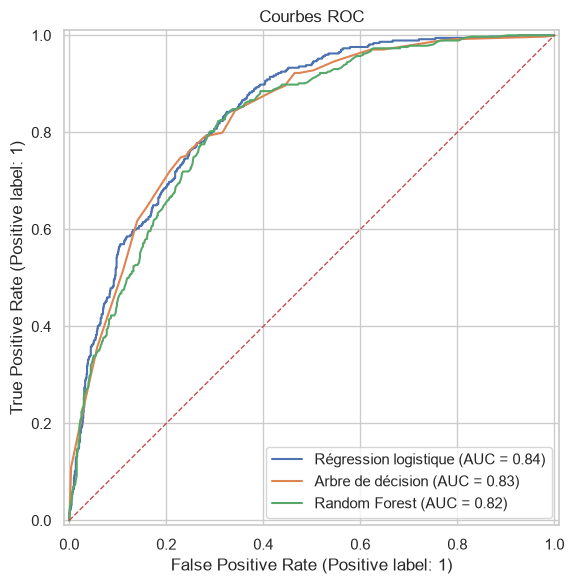

In [7]:
plt.figure(figsize=(8, 6))
ax = plt.gca()
for name, pipe in fitted_models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
plt.plot([0, 1], [0, 1], "--", linewidth=1)
plt.title("Courbes ROC")
plt.tight_layout()
plt.show()


## 7. Petite optimisation avec GridSearchCV

On ne cherche pas des centaines de réglages. On teste seulement quelques valeurs faciles à expliquer.

GridSearchCV teste plusieurs réglages, utilise la validation croisée et garde celui qui donne le meilleur ROC-AUC moyen.


In [8]:
# Le script et ce notebook appellent la même recherche sur cinq plis.
# Aucun résultat du jeu de test n'entre dans le choix des hyperparamètres.
best_models, grid_rows = optimize_models(X_train, y_train)
pd.DataFrame(grid_rows).set_index("model").rename(columns={
    "roc_auc_cv": "ROC-AUC CV", "best_params": "Meilleurs paramètres"
})


,ROC-AUC CV,Meilleurs paramètres
model,,
Régression logistique,0.845498,{'model__C': 10}
Arbre de décision,0.827368,"{'model__max_depth': 5, 'model__min_samples_le..."
Random Forest,0.847129,"{'model__max_depth': 8, 'model__min_samples_le..."


## 8. Évaluation finale sur le jeu de test

Le test n'a pas servi au choix des hyperparamètres. On l'utilise seulement à la fin pour vérifier la capacité de généralisation.


In [9]:
# Calculer et exporter les résultats avec les mêmes fonctions que le script.
# Les fichiers results/metrics.csv et results/best_parameters.json sont actualisés ensemble.
final_rows = [
    evaluate_model(name, pipe, X_test, y_test)
    for name, pipe in best_models.items()
]
results_df = save_results(final_rows, grid_rows)
results_df.set_index("model").round(4)



=== Régression logistique ===
  accuracy: 0.740
 precision: 0.506
    recall: 0.783
        f1: 0.615
   roc_auc: 0.841
Matrice de confusion:
[[749 286]
 [ 81 293]]

=== Arbre de décision ===
  accuracy: 0.752
 precision: 0.521
    recall: 0.781
        f1: 0.625
   roc_auc: 0.832
Matrice de confusion:
[[767 268]
 [ 82 292]]

=== Random Forest ===
  accuracy: 0.754
 precision: 0.524
    recall: 0.794
        f1: 0.631
   roc_auc: 0.842
Matrice de confusion:
[[765 270]
 [ 77 297]]


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Random Forest,0.7537,0.5238,0.7941,0.6312,0.8416
Régression logistique,0.7395,0.5060,0.7834,0.6149,0.8405
Arbre de décision,0.7516,0.5214,0.7807,0.6253,0.8319


## 9. Comprendre le seuil de décision : 40 %, 50 %, 60 %

La régression logistique renvoie une probabilité de churn. Par défaut, une probabilité supérieure ou égale à 50 % est classée comme churn.

On teste 40 %, 50 % et 60 % pour comprendre le compromis entre Recall et Precision.


In [10]:
log_model = best_models["Régression logistique"]
proba = log_model.predict_proba(X_test)[:, 1]

threshold_rows = []
for threshold in [0.40, 0.50, 0.60]:
    pred = (proba >= threshold).astype(int)
    threshold_rows.append({
        "Seuil": threshold,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "Clients signalés": int(pred.sum()),
    })

threshold_df = pd.DataFrame(threshold_rows).set_index("Seuil").round(4)
threshold_df


,Precision,Recall,F1,Clients signalés
Seuil,,,,
0.4,0.4629,0.8663,0.6034,700
0.5,0.5060,0.7834,0.6149,579
0.6,0.5408,0.7086,0.6134,490


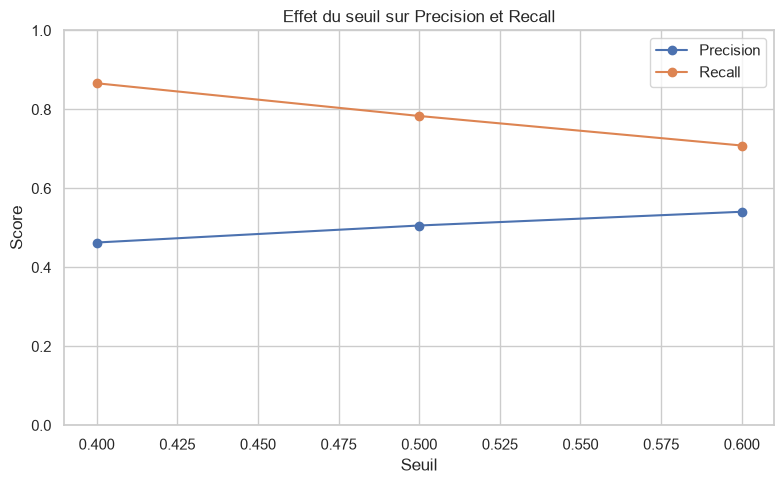

In [11]:
threshold_df[["Precision", "Recall"]].plot(marker="o", figsize=(8, 5))
plt.title("Effet du seuil sur Precision et Recall")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


### À dire à l'oral

> Si je baisse le seuil à 40 %, je détecte davantage de clients à risque, donc le Recall augmente, mais je crée aussi plus de fausses alertes. Si je monte le seuil à 60 %, je signale moins de clients mais je risque de manquer davantage de churners.

Il n'existe donc pas un seuil parfait : il dépend du coût métier des erreurs.


## 10. Recommandation simple

Pour ce projet étudiant, la **Régression Logistique** reste le modèle principal recommandé :
- ses performances recalculées sont proches de celles de la Random Forest sur ce test ;
- elle est plus simple à interpréter ;
- elle permet de produire une probabilité ;
- son seuil peut être adapté selon la stratégie de rétention.


## 11. Recommandations métier simples

Les analyses du projet montrent notamment des associations avec l'ancienneté, le type de contrat, les contrats mensuels, la fibre optique et les frais mensuels/totaux.

Une entreprise pourrait utiliser le modèle pour prioriser les clients à contacter :
1. le modèle calcule un risque de churn ;
2. les clients les plus à risque sont placés dans une liste ;
3. l'équipe rétention les contacte avec une offre ou une enquête de satisfaction.

Important : ces variables sont associées au churn dans les données. Elles ne prouvent pas une cause.


## 12. Limites du projet

1. Les données sont historiques : les comportements peuvent changer.
2. Le dataset ne contient pas toutes les raisons personnelles d'un départ.
3. Le modèle détecte des associations, pas les causes réelles du churn.
4. Le seuil métier idéal n'est pas défini sans connaître le coût des erreurs.
5. En production, il faudrait vérifier et réentraîner le modèle régulièrement.


## 13. Ce que j'ai appris

Ce projet m'a permis de comprendre que :
- nettoyer les données est essentiel ;
- une bonne Accuracy ne suffit pas si les classes sont déséquilibrées ;
- il faut séparer train et test pour évaluer la généralisation ;
- plusieurs métriques sont nécessaires pour comprendre les erreurs ;
- un modèle simple peut être préférable à un modèle plus complexe si les performances sont proches ;
- le choix du seuil dépend du besoin métier ;
- Machine Learning ne veut pas dire chercher le modèle le plus compliqué.


## Conclusion

Le projet suit une démarche complète mais simple : préparation, baseline, comparaison des modèles, analyse des erreurs, vérification du sur-apprentissage, petite optimisation, test de seuils et recommandation métier.

La **Régression Logistique** est le modèle privilégié pour sa simplicité. Ses performances sont proches de celles de la Random Forest sur le test utilisé.


## 14. Les quatre visuels de soutenance
Ces figures reprennent les modèles optimisés ci-dessus. Les fichiers PNG, PDF et tableaux sources sont enregistrés dans `results/figures/`.
Les coefficients sont des associations apprises, pas des preuves de causalité.


=== Référence naïve ===
  accuracy: 0.735
 precision: 0.000
    recall: 0.000
        f1: 0.000
   roc_auc: 0.500
Matrice de confusion:
[[1035    0]
 [ 374    0]]


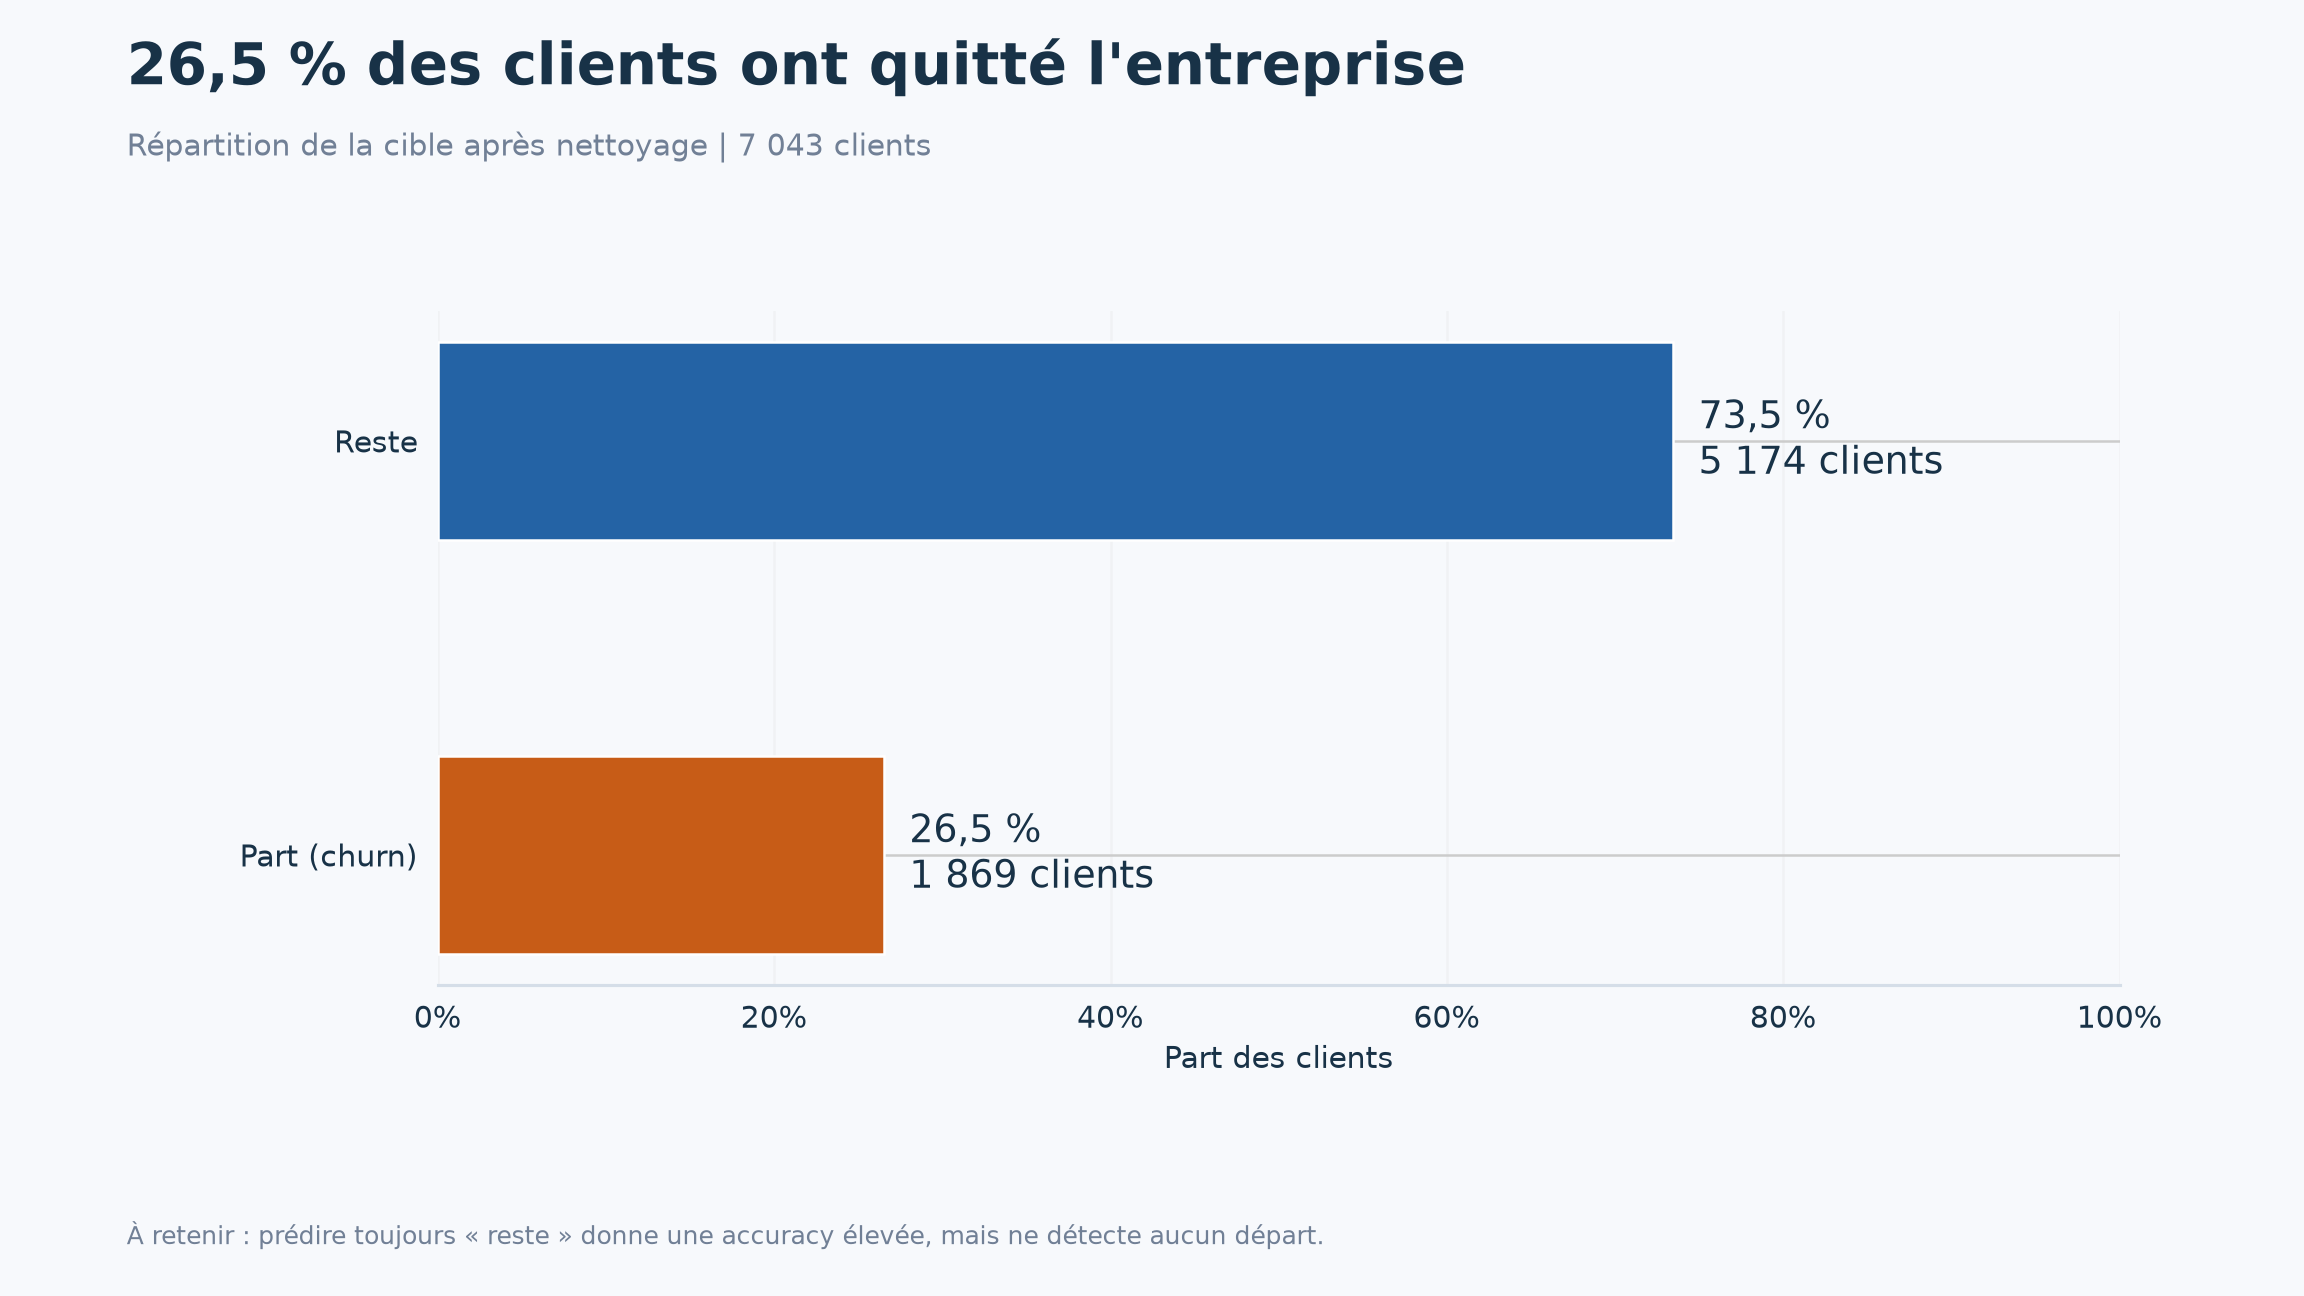

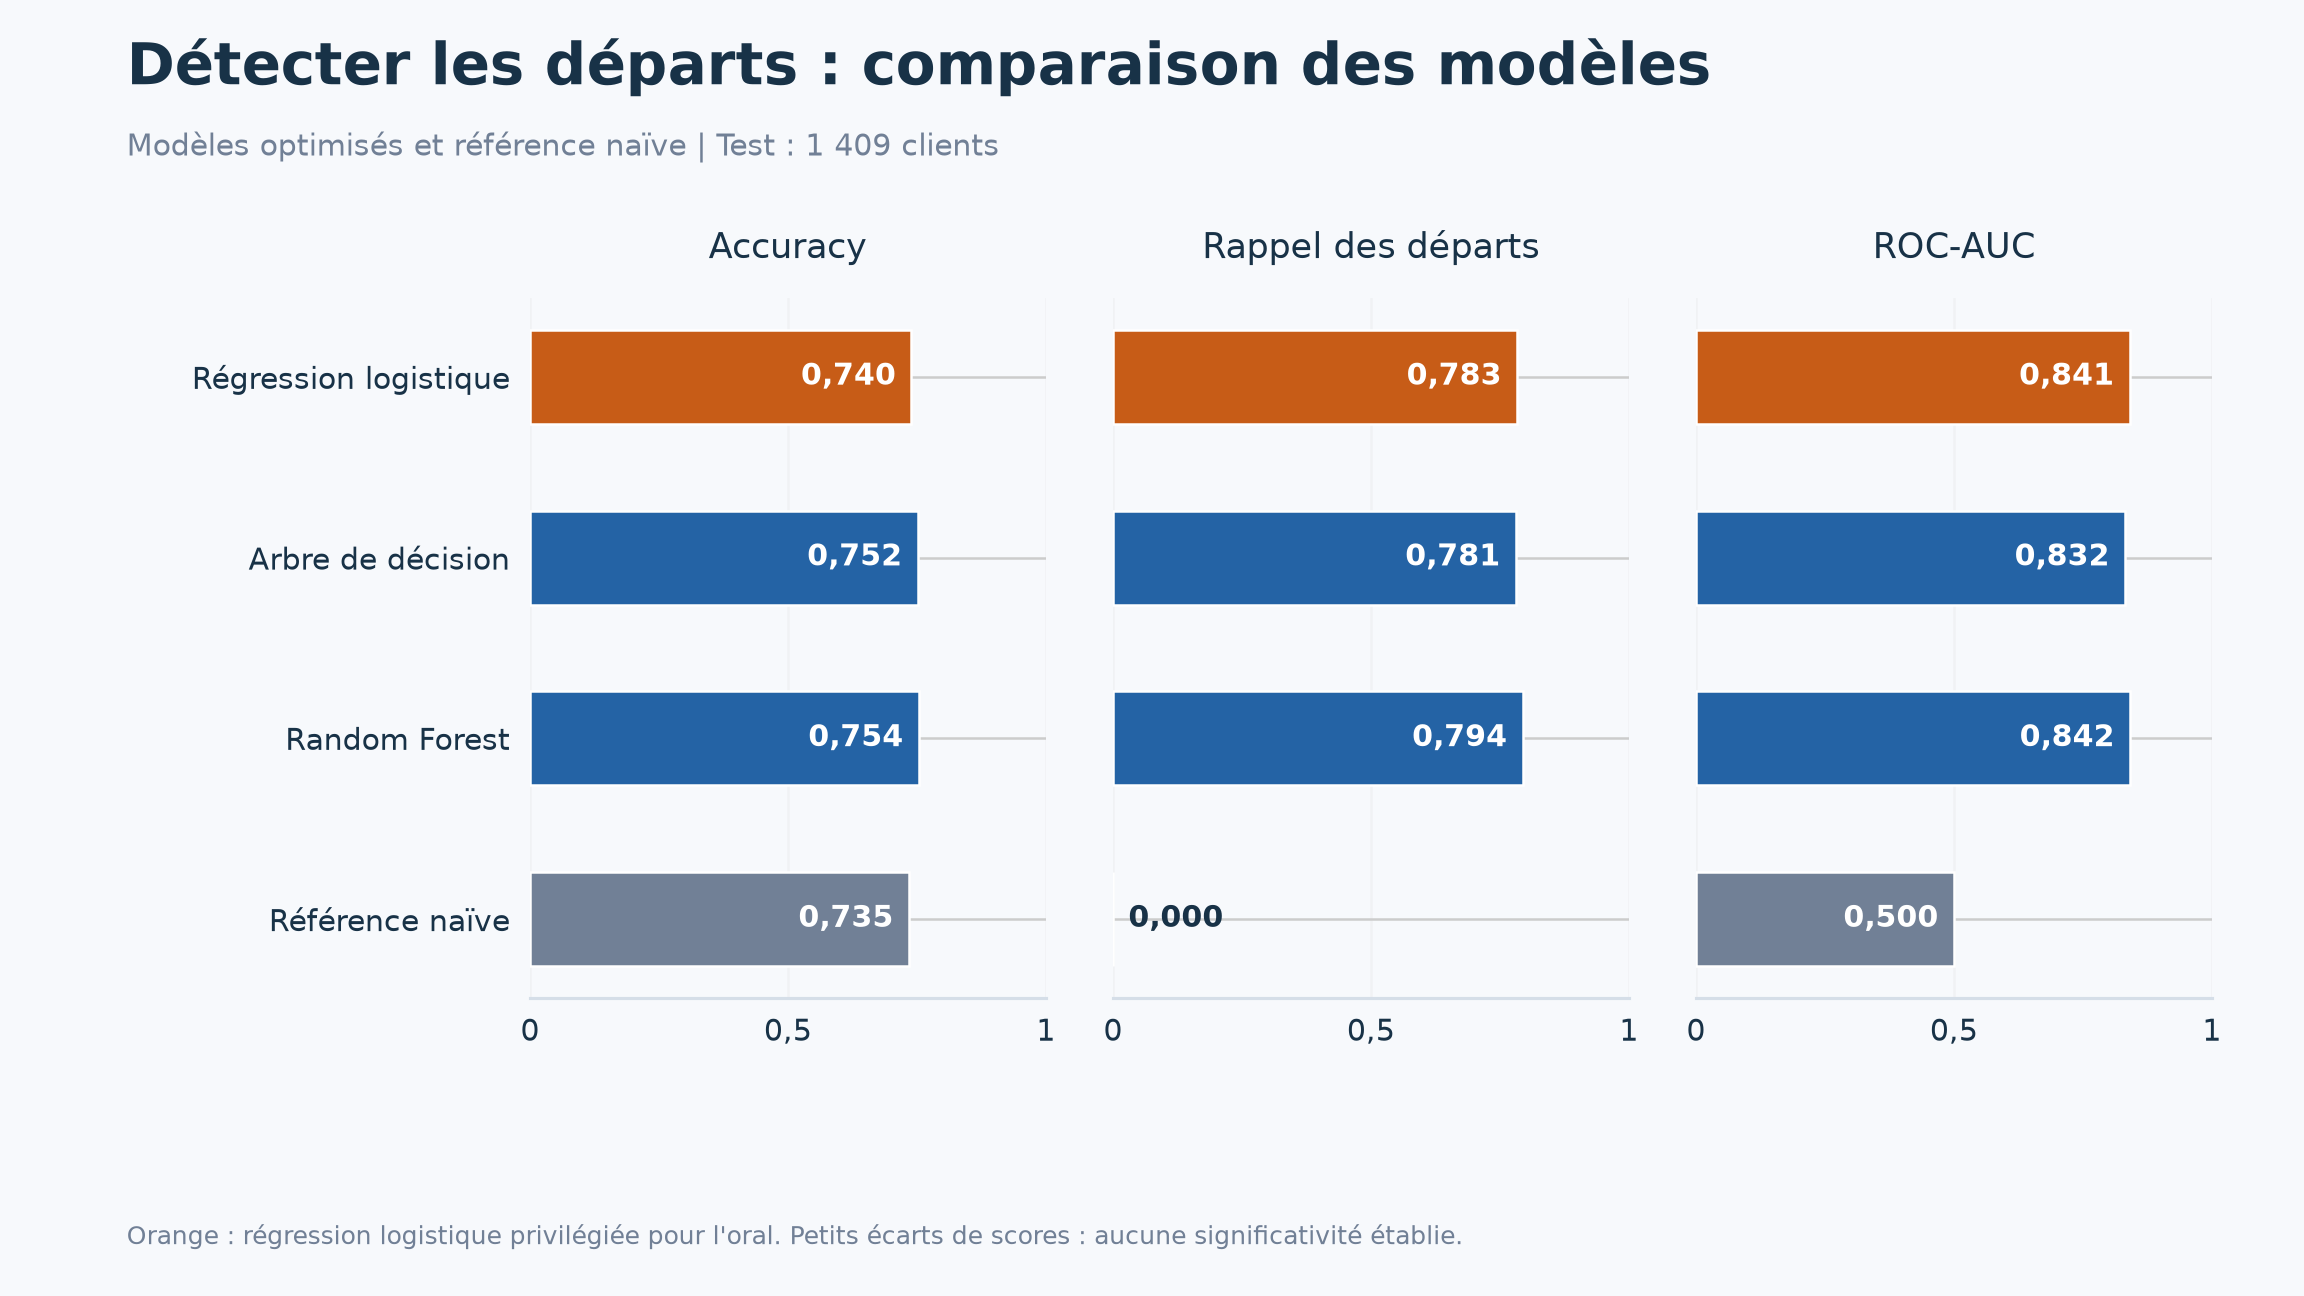

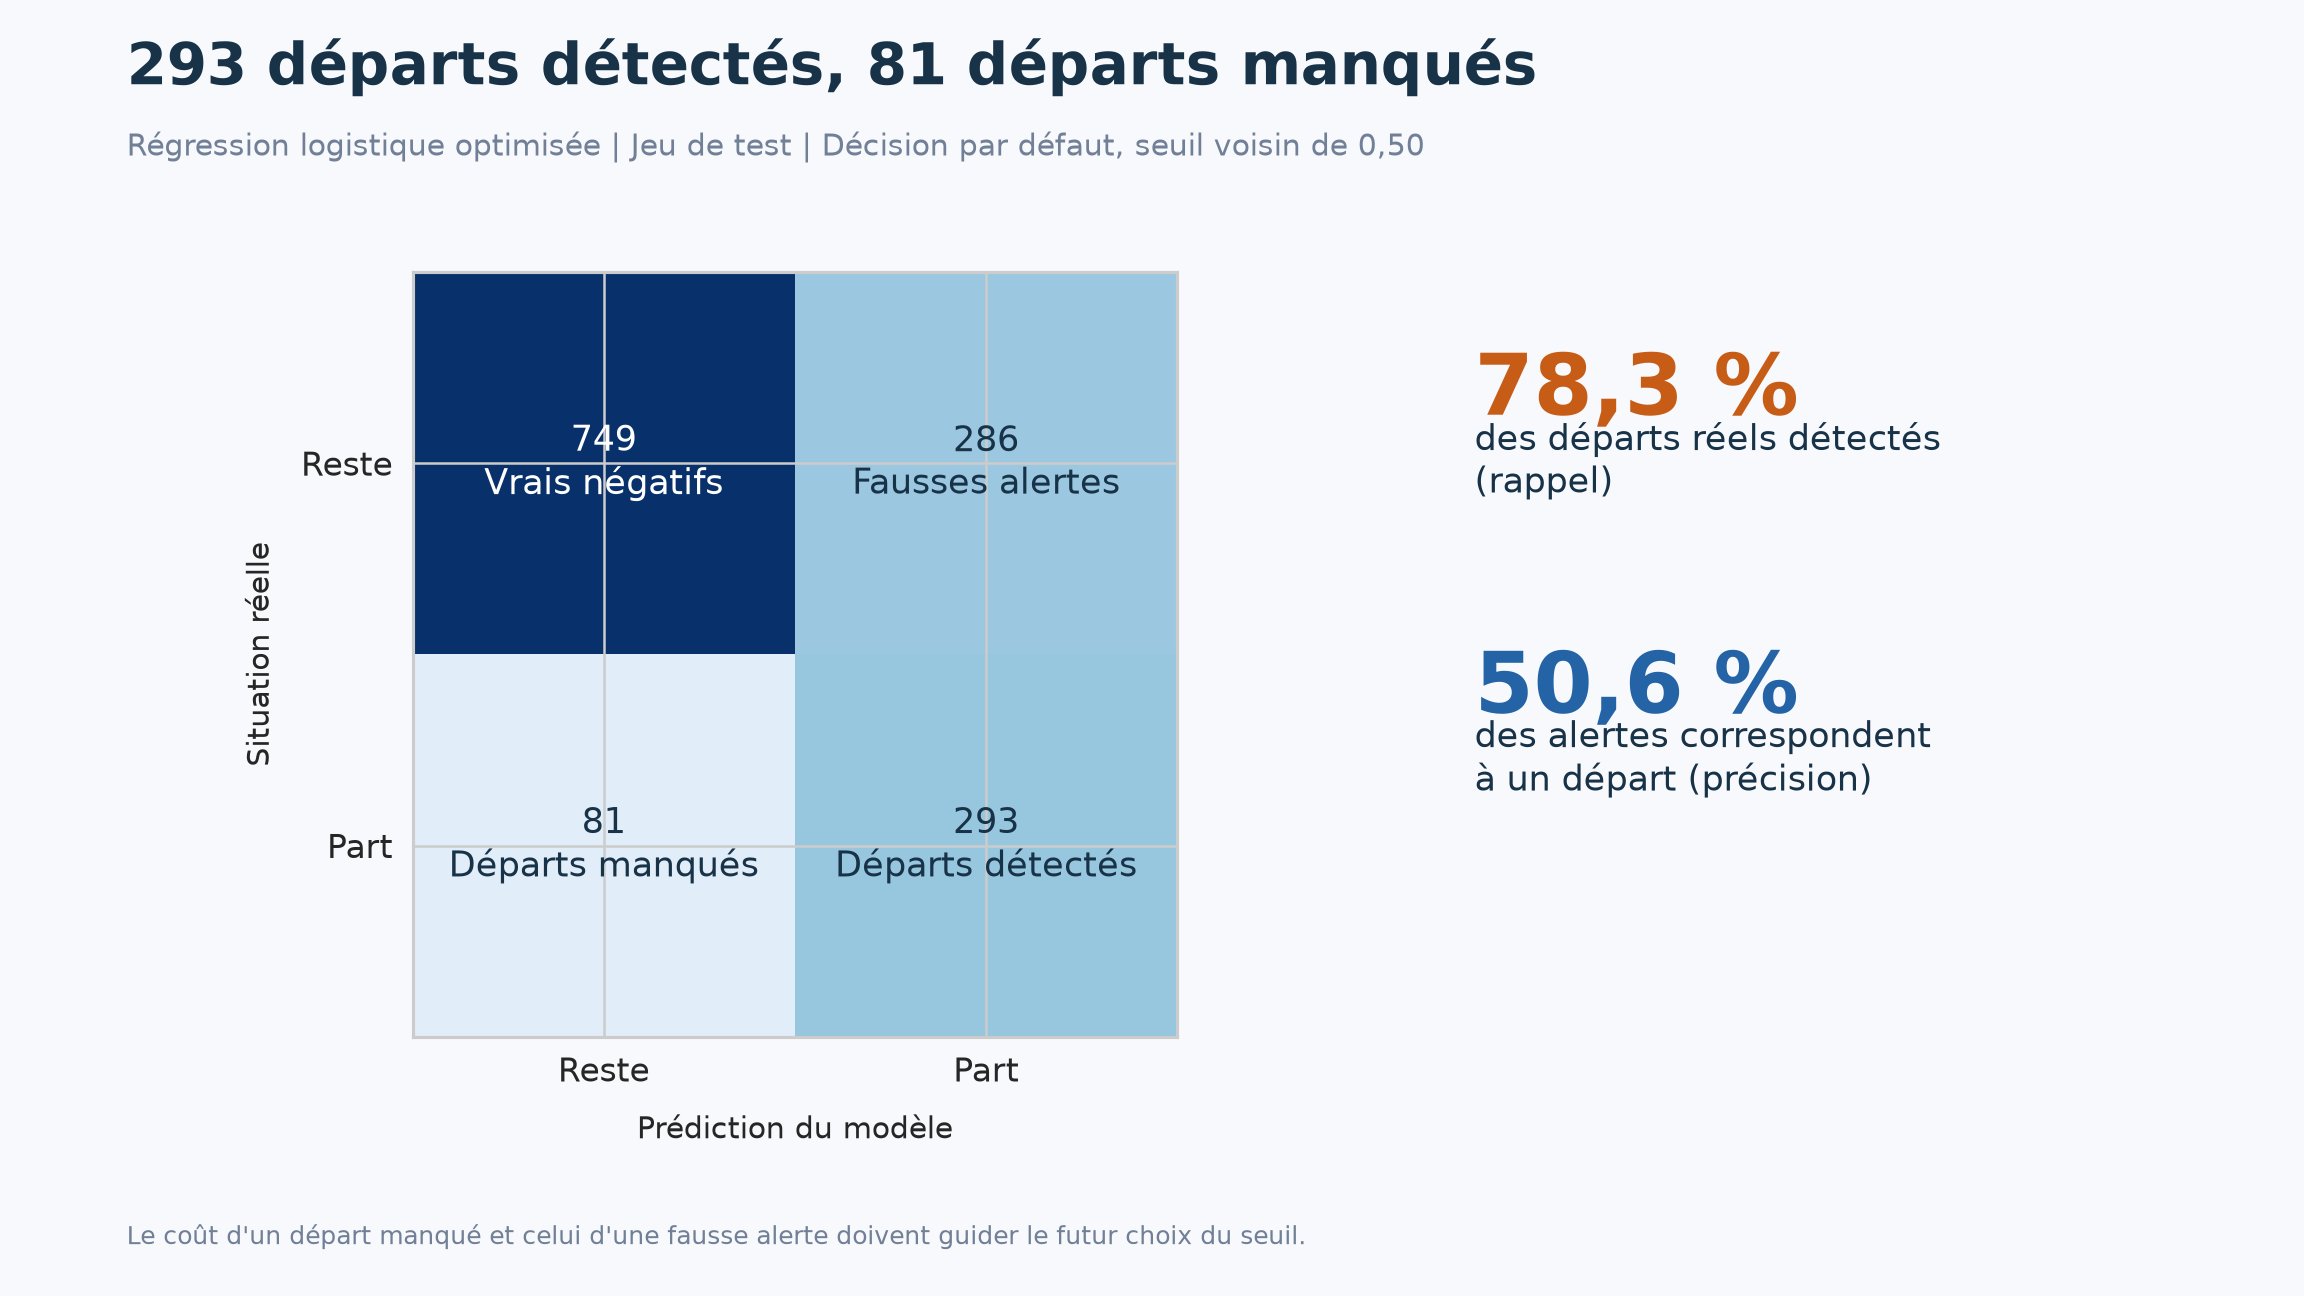

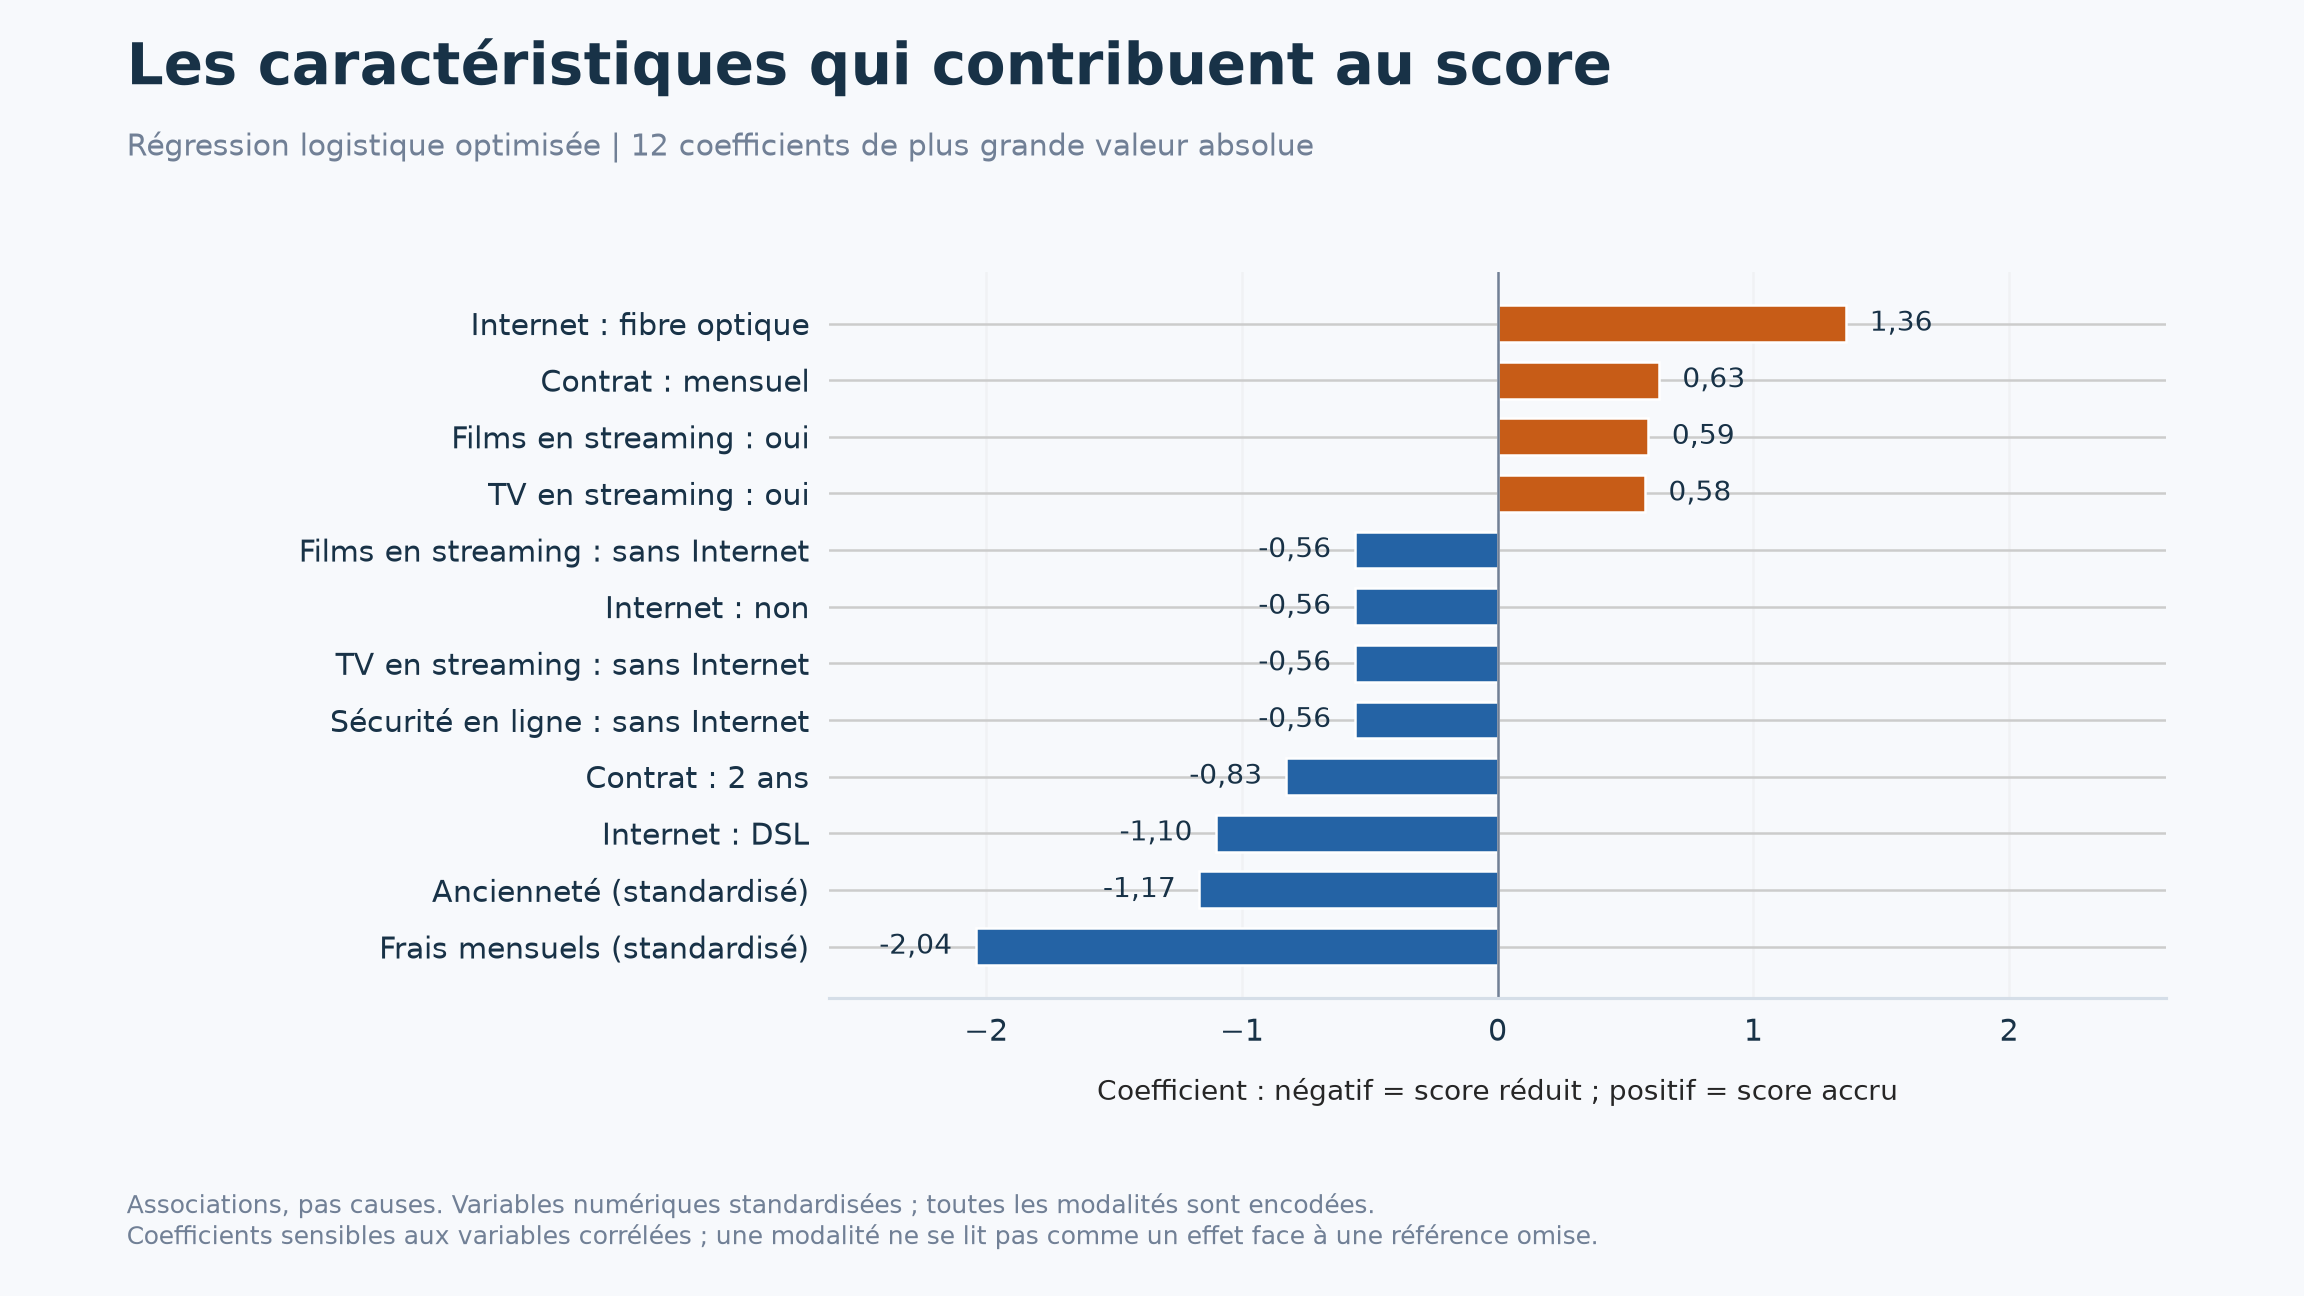

In [12]:
from src.visualize import export_visuals
# Réutiliser les modèles déjà entraînés et la baseline calculée sur le train.
# Aucun nouvel entraînement n’est nécessaire pour dessiner les quatre figures.
baseline_scores = evaluate_model("Référence naïve", dummy, X_test, y_test)
figure_paths = export_visuals(y, X_test, y_test, best_models, final_rows + [baseline_scores])
from IPython.display import Image, display
for figure_path in figure_paths:
    display(Image(filename=str(figure_path), width=960))
